# 📊 Notebook 2 : Analyse Exploratoire des Données (EDA)
**Projet StatApp - Scouting et Profilage de Joueurs**

L'objectif de ce notebook est d'explorer notre base de données nettoyée. Nous allons :
1. Comprendre la distribution globale de nos variables (Âge, Buts, xG...).
2. Analyser les corrélations entre les statistiques (ex: Expected Goals vs Buts réels).
3. Identifier les meilleurs joueurs par saison (Tops buteurs, passeurs).

In [4]:
import sys
import pandas as pd
from pathlib import Path

# 1. Configuration de l'environnement (Colab vs Local)
if 'google.colab' in sys.modules:
    print("🌐 Environnement Colab détecté.")
    # On s'assure que le dossier est bien là (si on ouvre directement le NB 2)
    if not Path('/content/Stat_app').exists():
        !git clone https://github.com/Aymanyah/Stat_app.git
    PROJECT_DIR = Path('/content/Stat_app')
else:
    print("💻 Environnement local détecté.")
    PROJECT_DIR = Path.cwd().parent 

# 2. Définition du chemin vers les données propres
DATA_CLEAN = PROJECT_DIR / "data" / "clean" / "dataset_aggregated.csv"

# 3. Chargement des données pour l'analyse
df = pd.read_csv(DATA_CLEAN)
print(f"✅ Données chargées avec succès ! ({df.shape[0]} lignes)")

💻 Environnement local détecté.
✅ Données chargées avec succès ! (6530 lignes)


In [5]:
# --- 1) IMPORTS ET CONFIGURATION DES CHEMINS ---
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Détection Colab / Local
if 'google.colab' in sys.modules:
    if not Path('/content/Stat_app').exists():
        !git clone https://github.com/Aymanyah/Stat_app.git
    PROJECT_DIR = Path('/content/Stat_app')
else:
    PROJECT_DIR = Path.cwd().parent 

# Chargement des données propres
DATA_CLEAN = PROJECT_DIR / "data" / "clean" / "dataset_aggregated.csv"
df = pd.read_csv(DATA_CLEAN)

print(f"✅ Données chargées : {df.shape[0]} lignes et {df.shape[1]} colonnes.")

✅ Données chargées : 6530 lignes et 44 colonnes.


In [6]:
# 1. On affiche les colonnes telles que Pandas les voit (tu repéreras vite les espaces)
print("--- Noms avant nettoyage ---")
print(df.columns.tolist()[:25]) # On affiche les 25 premières

# 2. LA SOLUTION MAGIQUE : On supprime les espaces au début et à la fin de TOUTES les colonnes
df.columns = df.columns.str.strip()

# 3. Si 'season' est resté coincé dans l'index suite au Notebook 1, on le remet en colonne normale
if 'season' not in df.columns:
    df = df.reset_index()

# 4. On vérifie que nos 3 colonnes problématiques sont bien là
print("\n--- Vérification ---")
print("Colonnes réparées présentes :", [c for c in ['season', 'G', 'xG'] if c in df.columns])

--- Noms avant nettoyage ---
['player', 'season', 'age', 'born', 'Minutes de jeu', '# 90 min jouées', 'G', 'A', 'G+A', 'G-PK', 'G+A-PK', 'xG', 'xAG', 'xG+xAG', 'npxG', 'npxG+xAG', '% dribble  réussis', '% passes réussies', '% passes courtes réussies', '% passes moyennes réussies', '% passes longues réussies', '% duels aériens gagnés', 'xG / Tir', 'Valeur marchande (euros)', 'Chevauchée avant  >5m']

--- Vérification ---
Colonnes réparées présentes : ['season', 'G', 'xG']


## 1. Les Meilleurs Performeurs par Saison
Nous utilisons une fonction personnalisée pour extraire le Top 10 des joueurs selon une statistique donnée (Buts, xG, Passes décisives, etc.) pour chaque saison.

In [7]:
def top10_per_season(dataframe, season, stat_column, min_minutes=900):
    """
    Retourne le Top 10 des joueurs pour une saison et une statistique donnée,
    en excluant ceux qui n'ont pas assez joué.
    """
    # 1. On isole la saison voulue
    df_season = dataframe[dataframe['season'] == season].copy()
    
    # 2. LE FILTRE MAGIQUE : On exclut ceux qui ont joué moins de X minutes
    if 'Minutes de jeu' in df_season.columns:
        df_season = df_season[df_season['Minutes de jeu'] >= min_minutes]
        
    # 3. On trie par la statistique voulue (du plus grand au plus petit)
    top_10 = df_season.sort_values(by=stat_column, ascending=False).head(10)
    
    # 4. On prépare un bel affichage
    # J'ai ajouté 'Minutes de jeu' dans l'affichage pour que tu puisses vérifier !
    result = top_10[['player', 'team', 'league', 'Minutes de jeu', stat_column]]
    result = result.reset_index(drop=True)
    result.index += 1 # Pour que le classement commence à 1 et pas 0
    
    return result

# --- TEST ---
print("--- TOP 10 BUTEURS (2023) - Min 900 minutes ---")
display(top10_per_season(df, 2023, 'G', min_minutes=900))

print("--- TOP 10 PASSEURS (2023) - Min 900 minutes ---")
display(top10_per_season(df, 2023, 'A', min_minutes=900))

# Les joueurs qui ont le plus de Expected Goals (xG)
print("--- TOP 10 xG (2023) ---")
display(top10_per_season(df, 2023, 'xG', min_minutes=900))

# Les joueurs qui tirent le plus
print("--- TOP 10 TIREURS (2023) ---")
display(top10_per_season(df, 2023, 'Tirs', min_minutes=900))

--- TOP 10 BUTEURS (2023) - Min 900 minutes ---


,player,team,league,Minutes de jeu,G
1,Vitinha,Paris S-G,FRA-Ligue 1,6098.0,1.18
2,Serhou Guirassy,Stuttgart,GER-Bundesliga,2208.0,1.14
3,Harry Kane,Bayern Munich,GER-Bundesliga,2839.0,1.14
4,Kylian Mbappé,Paris S-G,FRA-Ligue 1,2158.0,1.13
5,Erling Haaland,Manchester City,ENG-Premier League,2552.0,0.95
6,Alexander Isak,Newcastle Utd,ENG-Premier League,2255.0,0.84
7,Benjamin Šeško,RB Leipzig,GER-Bundesliga,1526.0,0.83
8,Artem Dovbyk,Girona,ESP-La Liga,2587.0,0.83
9,Alexander Sørloth,Villarreal,ESP-La Liga,2489.0,0.83
10,Callum Wilson,Newcastle Utd,ENG-Premier League,991.0,0.82


--- TOP 10 PASSEURS (2023) - Min 900 minutes ---


,player,team,league,Minutes de jeu,A
1,Vitinha,Paris S-G,FRA-Ligue 1,6098.0,0.74
2,Kevin De Bruyne,Manchester City,ENG-Premier League,1221.0,0.74
3,Victor Boniface,Leverkusen,GER-Bundesliga,1546.0,0.47
4,Leroy Sané,Bayern Munich,GER-Bundesliga,2137.0,0.46
5,Nico Williams,Athletic Club,ESP-La Liga,2263.0,0.44
6,Brennan Johnson,Tottenham,ENG-Premier League,2085.0,0.43
7,Florian Wirtz,Leverkusen,GER-Bundesliga,2372.0,0.42
8,Pascal Stenzel,Stuttgart,GER-Bundesliga,1064.0,0.42
9,Kieran Trippier,Newcastle Utd,ENG-Premier League,2236.0,0.40
10,Lucas Vázquez,Real Madrid,ESP-La Liga,1419.0,0.38


--- TOP 10 xG (2023) ---


,player,team,league,Minutes de jeu,xG
1,Erling Haaland,Manchester City,ENG-Premier League,2552.0,1.030
2,Harry Kane,Bayern Munich,GER-Bundesliga,2839.0,0.970
3,Victor Boniface,Leverkusen,GER-Bundesliga,1546.0,0.900
4,Kylian Mbappé,Paris S-G,FRA-Ligue 1,2158.0,0.870
5,Serhou Guirassy,Stuttgart,GER-Bundesliga,2208.0,0.850
6,Artem Dovbyk,Girona,ESP-La Liga,2587.0,0.840
7,Alexander Isak,Newcastle Utd,ENG-Premier League,2255.0,0.810
8,Callum Wilson,Newcastle Utd,ENG-Premier League,991.0,0.800
9,Neal Maupay,Brentford,ENG-Premier League,1432.0,0.775
10,Mohamed Salah,Liverpool,ENG-Premier League,2534.0,0.750


--- TOP 10 TIREURS (2023) ---


,player,team,league,Minutes de jeu,Tirs
1,Vitinha,Paris S-G,FRA-Ligue 1,6098.0,10.998025
2,Neal Maupay,Brentford,ENG-Premier League,1432.0,6.683673
3,Nadiem Amiri,Mainz 05,GER-Bundesliga,1401.0,5.397260
4,Darwin Núñez,Liverpool,ENG-Premier League,2047.0,4.713656
5,Kylian Mbappé,Paris S-G,FRA-Ligue 1,2158.0,4.666667
6,Kevin Behrens,Wolfsburg,GER-Bundesliga,1878.0,4.546218
7,Niclas Füllkrug,Werder Bremen,GER-Bundesliga,2392.0,4.532520
8,Harry Kane,Bayern Munich,GER-Bundesliga,2839.0,4.476190
9,Victor Boniface,Leverkusen,GER-Bundesliga,1546.0,4.418605
10,Carlos Baleba,Brighton,ENG-Premier League,1386.0,4.285714


## 2. Modélisation Basique : xG vs Buts (Surperformance)
Les *Expected Goals* mesurent la probabilité qu'un tir se transforme en but. En comparant les xG aux Buts réellement marqués via une régression linéaire, nous pouvons isoler les résidus : les joueurs avec un résidu positif marquent plus que ce que le modèle statistique prévoyait (surperformance).

--- TOP 10 SURPERFORMEURS (Buts réels > Buts attendus) ---


,player,season,G,xG,resid
3676,Luis Suárez,2020.0,1.50,0.580,0.892136
3677,Luis Suárez,2021.0,1.50,0.580,0.892136
239,Alexander Isak,2022.0,1.18,0.305,0.862808
6162,Vitinha,2023.0,1.18,0.315,0.852238
5814,Terem Moffi,2022.0,1.19,0.515,0.650840
2027,Gaëtan Laborde,2022.0,1.19,0.520,0.645555
2681,Jean-Philippe Mateta,2020.0,1.04,0.455,0.564260
2798,Joe Willock,2021.0,0.74,0.230,0.502083
2797,Joe Willock,2020.0,0.74,0.230,0.502083
2015,Gareth Bale,2020.0,1.08,0.570,0.482706


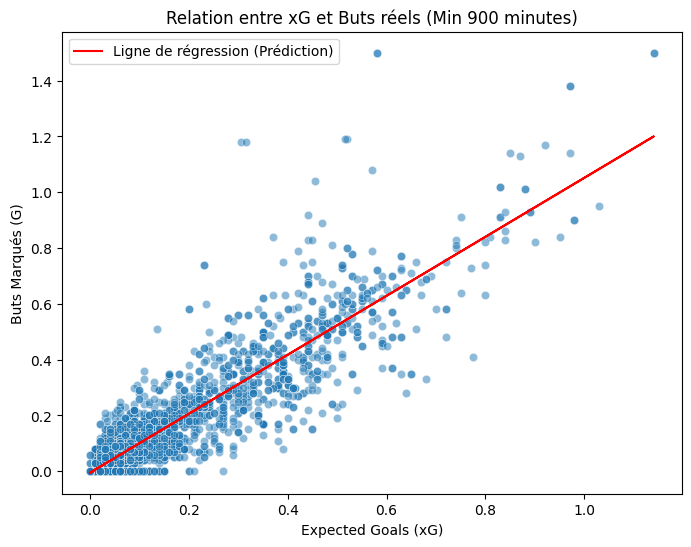

In [8]:
# --- IMPORTS MANQUANTS ---
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# 1. On filtre proprement UNE SEULE FOIS (plus de 900 minutes)
df_reg = df[df['Minutes de jeu'] >= 900].dropna(subset=['xG', 'G']).copy()

# 2. Préparation des variables avec le bon dataframe
X = df_reg[['xG']]
y = df_reg['G']

# 3. Modèle de régression
model = LinearRegression()
model.fit(X, y)

# 4. Prédiction et calcul des résidus
df_reg['pred'] = model.predict(X)
df_reg['resid'] = df_reg['G'] - df_reg['pred']

# 5. Affichage des plus gros "surperformeurs"
top_surperformers = df_reg.sort_values(by='resid', ascending=False).head(10)
print("--- TOP 10 SURPERFORMEURS (Buts réels > Buts attendus) ---")
display(top_surperformers[['player', 'season', 'G', 'xG', 'resid']])

# 6. Visualisation
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_reg, x='xG', y='G', alpha=0.5)
plt.plot(df_reg['xG'], df_reg['pred'], color='red', label='Ligne de régression (Prédiction)')

plt.title("Relation entre xG et Buts réels (Min 900 minutes)")
plt.xlabel("Expected Goals (xG)")
plt.ylabel("Buts Marqués (G)")
plt.legend()
plt.show()

### 📈 Interprétation des Résultats : Analyse de la Finition (xG vs Buts)

Cette modélisation par régression linéaire nous permet d'évaluer la qualité de finition des joueurs en comparant les **Expected Goals (xG)** (le nombre de buts qu'un joueur aurait dû marquer vu la qualité de ses tirs) avec ses **Buts réels (G)**.

**1. Analyse du Graphique (Scatter Plot)**
* **La ligne de régression (en rouge) :** Elle représente la tendance moyenne d'efficacité de notre échantillon. Un joueur situé exactement sur cette ligne marque exactement le nombre de buts attendus par le modèle.
* **Les joueurs au-dessus de la ligne :** Ce sont les profils dits "cliniques". Ils marquent plus de buts que ce que la probabilité de leurs tirs laissait présager. 
* **Les joueurs en dessous de la ligne :** Ce sont les joueurs en "sous-performance". Bien qu'ils parviennent à se procurer de bonnes occasions (xG élevé, donc bon placement ou bons appels), ils pèchent dans la finition ou font face à une variance négative (malchance, excellents arrêts des gardiens adverses).

**2. Analyse du Tableau des Résidus (Surperformance)**
Le tableau classe les joueurs selon leur "résidu" mathématique (Différence entre les Buts réels et les Buts prédits). 
Un résidu positif élevé peut s'interpréter de deux manières dans le scouting analytique :
1. **Un talent exceptionnel à la finition :** Les attaquants de classe mondiale (ex: Son Heung-min, Lionel Messi) ont historiquement toujours surperformé leurs xG sur le long terme car ils sont capables de marquer dans des positions très difficiles (faible probabilité xG).
2. **Une variance statistique (La chance) :** Sur une seule saison, un joueur moyen peut se retrouver dans ce Top 10 s'il connaît une période de réussite insolente. C'est un point d'attention crucial pour les recruteurs (Scouts) : acheter un joueur uniquement sur cette surperformance annuelle peut être risqué s'il y a une "régression vers la moyenne" la saison suivante.

**Conclusion pour le scouting :**
Cette métrique est essentielle pour repérer d'une part les tueurs devant le but (surperformance chronique), et d'autre part les attaquants sous-cotés qui se procurent énormément d'occasions (fort xG) mais qui ont juste manqué de réussite cette année-là.

In [10]:
import os
import pandas as pd

chemin_final = None
chemin_transformed = None

print("🔍 Recherche automatique des fichiers en cours...\n")

# 1. Le détective fouille dans tout ton dossier Stat_app
for root, dirs, files in os.walk("/home/onyxia/Stat_app/"):
    for file in files:
        if file == "all_leagues_merged_final_df.csv":
            chemin_final = os.path.join(root, file)
        elif file == "all_leagues_merged_transformed.csv":
            chemin_transformed = os.path.join(root, file)

print(f"📍 Chemin 'final_df' trouvé : {chemin_final}")
print(f"📍 Chemin 'transformed' trouvé : {chemin_transformed}\n")

# 2. Si le détective a trouvé les deux fichiers, il fait la comparaison
if chemin_final and chemin_transformed:
    print("⏳ Chargement des données (ça peut prendre quelques secondes)...")
    df_final = pd.read_csv(chemin_final, low_memory=False)
    df_transformed = pd.read_csv(chemin_transformed, low_memory=False)
    
    print("-" * 50)
    print(f"📊 Taille de 'final_df' : {df_final.shape[0]} lignes et {df_final.shape[1]} colonnes")
    print(f"📊 Taille de 'transformed' : {df_transformed.shape[0]} lignes et {df_transformed.shape[1]} colonnes")
    
    colonnes_en_commun = set(df_final.columns).intersection(set(df_transformed.columns))
    print(f"✅ Ils ont {len(colonnes_en_commun)} colonnes en commun.")
    print("-" * 50)
    
elif not chemin_final:
    print("❌ Je n'ai pas trouvé le fichier 'all_leagues_merged_final_df.csv'. As-tu bien exécuté le notebook EDA_final_df.ipynb jusqu'à la fin ?")
elif not chemin_transformed:
    print("❌ Je n'ai pas trouvé le fichier 'all_leagues_merged_transformed.csv'.")

🔍 Recherche automatique des fichiers en cours...

📍 Chemin 'final_df' trouvé : /home/onyxia/Stat_app/Data_merged_with_market_value/all_leagues_merged_final_df.csv
📍 Chemin 'transformed' trouvé : /home/onyxia/Stat_app/data/raw/all_leagues_merged_transformed.csv

⏳ Chargement des données (ça peut prendre quelques secondes)...
--------------------------------------------------
📊 Taille de 'final_df' : 10015 lignes et 106 colonnes
📊 Taille de 'transformed' : 10015 lignes et 44 colonnes
✅ Ils ont 9 colonnes en commun.
--------------------------------------------------
